# fase 2 do Churn Intelligence — modelo preditivo e explicabilidade

nesse notebook, vamo entrar na fase 2 do projeto, treinando o modelo preditivo de churn e extraindo explicações por clientes usando SHAP. a EDA da fase 1a já mostrou que as features do dataset têm relações predominantemente não-lineares com o target, então já tá decidido que o ideal pra esse caso, é usar modelos baseados em árvore.

entre os modelos baseados em árvore, o XGBoost foi o escolhido já que é a implementação mais madura e otimizada de gradient boosting disponível. diferente do Random Forest, que treina árvores em paralelo e independentes, o XGBoost treina sequencialmente, com cada árvore aprendendo especificamente dos erros da anterior, o que tende a capturar padrões sutis de churn com mais precisão.

o objetivo desse notebook é treinar e salvar o modelo, desenvolver a explicabilidade com valores SHAP por cliente e o score de evitabilidade e finalizar o que vai alimentar o pipeline de RAG na fase 3 e o Streamlit da fase 4.

o dataset do Kaggle e as reclamações do Reclame Aqui são de empresas diferentes. a intenção original do projeto era integrar as reclamações como feature agregada de sentimento que simulariam o comportamento de clientes da empresa no modelo, criando perfis de reclamação baseados em nota, status de resolução e sentimento.

mas, na prática, a API pública do Reclame Aqui não retornou essas colunas com qualidade suficiente (score, status de resolução e nota do cliente vieram completamente vazios ou sem variabilidade). sem esses dados, qualquer linkagem com o dataset do Kaggle seria puramente arbitrária e adicionaria ruído ao modelo sem base empírica.

então, decidi redirecionar as reclamações para o RAG na fase 3, onde o
texto real das reclamações tem papel direto e natural, contextualizando os
motivos de churn identificados pelo SHAP com experiências reais de clientes
insatisfeitos.

In [1]:
# versões utilizadas neste notebook
# pra reproduzir o ambiente, descomente e execute:

# !pip install pandas==2.2.2 numpy==2.0.2 scikit-learn==1.6.1 \
#   xgboost==3.2.0 shap==0.51.0 ucimlrepo==0.0.7 \
#   matplotlib==3.10.0 seaborn==0.13.2 scipy==1.16.3

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import requests
import json
import shap
from io import BytesIO
from xgboost import XGBClassifier
from sklearn.model_selection import (RandomizedSearchCV, StratifiedKFold,
                                     train_test_split)
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

In [2]:
# vamo carregar, aqui nesse notebook, os artefatos criados na fase 1a do projeto

df = pd.read_csv('https://raw.githubusercontent.com/meurii/churn-intelligence/refs/heads/main/data/churn_clean.csv')

url_preprocessor = 'https://raw.githubusercontent.com/meurii/churn-intelligence/main/models/preprocessor.joblib'
preprocessor = joblib.load(BytesIO(requests.get(url_preprocessor).content))

# vamo confirmar se eles foram carregados corretamente
print(f'dataset: {df.shape}')
print(f'preprocessor: {type(preprocessor).__name__}')

print(type(preprocessor))
print(preprocessor)


dataset: (7010, 20)
preprocessor: ColumnTransformer
<class 'sklearn.compose._column_transformer.ColumnTransformer'>
ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('bin', OrdinalEncoder(),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'PaperlessBilling',
                                  'SeniorCitizen']),
                                ('nom',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['MultipleLines', 'InternetService',
                                  'OnlineSecurity', 'OnlineBackup',
                                  'DeviceProtection', 'TechSupport',
                                  'StreamingTV', 'StreamingMovies', 'Contract',
                                  'Paym

a separação de X e y já foram feitos na fase 1a do projeto, apenas com o propósito de definir e salvar o preprocessor. aqui, a gente precisa repetir o processo porque o modelo precisa ser treinado e avaliado.

o preprocessor salvo antes precisa ser aplicado aqui de forma consistente sobre os mesmos dados que o modelo vai ver, e o random_state=42 é o que vai garantir que o resultado é idêntico ao da fase 1a.

In [3]:
# antes de definir o Pipeline, vamo separar X e y
X = df.drop(columns=['Churn'])
y = df['Churn']

# vamo fazer o split estratificado
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

a gente tbm já viu na fase 1a que o dataset é desbalanceado, então, pra corrigir esse desbalanceamento, vamo usar aqui o scale_pos_weight (já que ele é nativo do XGBoost) que vai dizer ao modelo quanto peso dar aos exemplos positivos durante o treinamento, forçando ele a levar a classe minoritária mais a sério.

scale_pos_weight calculado: 2.7739
              precision    recall  f1-score   support

       ficou       0.87      0.79      0.83      1031
    cancelou       0.54      0.68      0.60       371

    accuracy                           0.76      1402
   macro avg       0.71      0.74      0.72      1402
weighted avg       0.78      0.76      0.77      1402

AUC-ROC - XGBoost: 0.8232


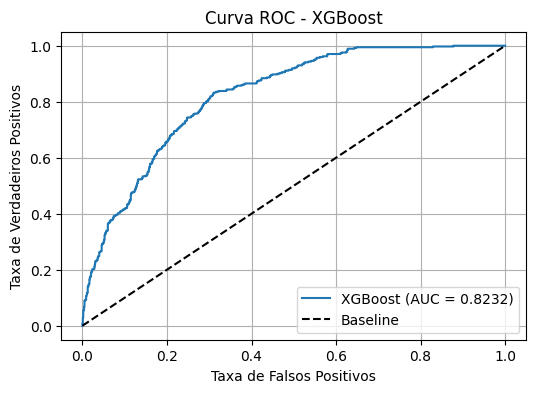

In [4]:
from sklearn.pipeline import Pipeline

# vamo calcular o scale_pos_weight dinamicamente, sem hardcodar

neg = (y_treino == 0).sum()
pos = (y_treino == 1).sum()
spw = neg / pos

# vamo incluir esse print aqui só pra acompanhar o processo
# e confirmar que o valor, era o esperado (aprox. 2.7)
print(f'scale_pos_weight calculado: {spw:.4f}')

# e, depois, já criar o modelo, inicialmente, com parâmetros default

pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        scale_pos_weight=spw,
        random_state=42,
        eval_metric='logloss'
    ))
])
pipeline_xgb.fit(X_treino, y_treino)

y_pred_pipeline_xgb = pipeline_xgb.predict(X_teste)
print(classification_report(y_teste, y_pred_pipeline_xgb, target_names=['ficou', 'cancelou']))

probabilidades_pipeline_xgb = pipeline_xgb.predict_proba(X_teste)[:, 1]
auc_pipeline_xgb = roc_auc_score(y_teste, probabilidades_pipeline_xgb)
fpr_pipeline_xgb, tpr_pipeline_xgb, _ = roc_curve(y_teste, probabilidades_pipeline_xgb)
print(f"AUC-ROC - XGBoost: {auc_pipeline_xgb:.4f}")

# curva ROC
plt.figure(figsize=(6, 4))
plt.plot(fpr_pipeline_xgb, tpr_pipeline_xgb, label=f'XGBoost (AUC = {auc_pipeline_xgb:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Baseline')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - XGBoost')
plt.legend()
plt.grid(True)
plt.show()

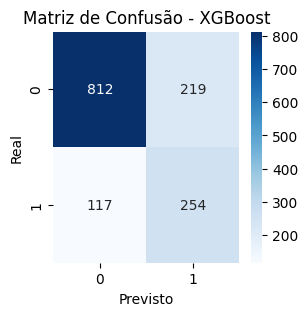

In [5]:
# vamo completar a análise com a matriz de confusão

matriz_pipeline_xgb = confusion_matrix(y_teste, y_pred_pipeline_xgb)
plt.figure(figsize=(3, 3))
sns.heatmap(matriz_pipeline_xgb, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - XGBoost')
plt.show()

o classification report mostra que o modelo identifica bem quem vai ficar (que é a classe majoritária no dataset), com poucos falsos positivos nessa classe, retornando precisão de 0.87 e recall de 0.79;

já na classe "cancelou" (que é a minoritária) tivemos:
- recall de 0.68, o que significa que o modelo identificou 68% dos clientes que de fato vão cancelar;
- precisão de 0.54, ou seja: de todos os clientes que o modelo sinalizou como churn, 54% realmente cancelaram, o restante são acionamentos desnecessários. a depender do custo dessa ação de retenção, errar pra esse lado não é um problema tão grave.

analisando a matriz de confusão, vemos que, de um total de 1402 clientes no conjunto de teste, o modelo errou na classificação de 336 casos:
- 219 falsos negativos, que são clientes que vão cancelar mas o modelo previu que ficariam. aqui a ampresa acaba perdendo os clientes sem nem ter tido chance de agir;
- 117 falsos positivos, que são clientes que ficariam mas o modelo previu cancelamento. o custo aqui é apenas acionar uma ação de retenção desnecessária.

esse é o resultado de um baseline sem otimização de hiperparâmetros, como se fosse um piso de performance estabelecido. sendo assim, esses valores podem ser considerados um ponto de partida razoável com um modelo funcional, mas vamo incluir essa otimização pra tentar melhorar esses resultados.

In [6]:
# vamo fazer o cross-validation estratificado pra buscar uma avaliação de desempenho mais robusta

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_xgb = cross_val_score(pipeline_xgb, X_treino, y_treino, cv=cv, scoring='roc_auc')
print(f"AUC-ROC médio - XGBoost: {scores_xgb.mean():.4f} ± {scores_xgb.std():.4f}")

AUC-ROC médio - XGBoost: 0.8187 ± 0.0084


o AUC-ROC médio na validação cruzada foi de 0.8187 (com desvio padrão de 0.0084), enquanto que o AUC-ROC no teste foi de 0.8232. essa proximidade entre esses dois valores é sinal de que o modelo não está overfittando, já que ele generaliza de forma consistente para dados que não viu durante o treinamento. o valor baixo do desvio padrão tbm mostra que o modelo é estável entre os folds.

com os hiperparâmetros e os ranges que vamo rolar na otimização, teríamos centenas de combinações, cada uma rodando 5 folds de cv. além de lento, não agregaria performance extra significativa. então, vamo usar n_iter=50 pra escolher, de forma randomizada, 50 combinações dentro dessas centenas de possibilidades que já cobrem bem as regiões relevantes.

In [7]:
# vamo rodar o RandomizedSearch pra otimizar os hiperparâmetros

param_dist = {
    'classifier__n_estimators':     [100, 200, 300, 500],
    'classifier__max_depth':        [3, 4, 5, 6],
    'classifier__learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'classifier__subsample':        [0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

search = RandomizedSearchCV(
    pipeline_xgb,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    # vamo usar n_jobs=1 pra garantir reprodutibilidade completa, mesmo demorando mais de rodar
    n_jobs=1
)
search.fit(X_treino, y_treino)

print(f'melhores parâmetros: {search.best_params_}')
print(f'melhor AUC-ROC (CV): {search.best_score_:.4f}')

melhores parâmetros: {'classifier__subsample': 0.8, 'classifier__n_estimators': 500, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.9}
melhor AUC-ROC (CV): 0.8497


os melhores parâmetros encontrados (n_estimators=500, max_depth=3 e learning_rate=0.01) ficaram no limite dos valores do espaço de busca original. nesse caso, o modelo pode estar sinalizando que quer ir mais longe nessa direção. então, vamo expandir o range e rodar de novo pra confirmar se esses são realmente os valores ótimos ou se existe uma configuração melhor

In [8]:
# vamo rodar o RandomizedSearch pra otimizar os hiperparâmetros

param_dist = {
    'classifier__n_estimators':     [300, 500, 1000, 1200],
    'classifier__max_depth':        [2, 3, 4, 5],
    'classifier__learning_rate':    [0.001, 0.01, 0.05, 0.1],
    'classifier__subsample':        [0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

search_final = RandomizedSearchCV(
    pipeline_xgb,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=1
)
search_final.fit(X_treino, y_treino)

print(f'melhores parâmetros: {search_final.best_params_}')
print(f'melhor AUC-ROC (CV): {search_final.best_score_:.4f}')

melhores parâmetros: {'classifier__subsample': 0.7, 'classifier__n_estimators': 1200, 'classifier__max_depth': 2, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.7}
melhor AUC-ROC (CV): 0.8506


nessa segunda rodada, o learning_rate se manteve em 0.01, confirmando que esse é o valor ótimo pra esse parâmetro (o modelo realmente prefere aprender devagar). os outros parâmetros continuaram nos limites do novo espaço de busca que a gente delimitou: o max_depth desceu pra 2, mas como esse já é o mínimo prático pra XGBoost não tem discussão; o n_estimators subiu pro limite superior (1200) e, por último, subsample e colsample_bytree tbm chegaram nos limites inferiores, sugerindo que o modelo prefere subamostrar mais.

apesar disso, o ganho de AUC entre as rodadas foi de apenas 0.0009. isso mostra que continuar expandindo essa busca tem custo computacional alto e um ganho quase irrelevante pro negócio

sendo assim, vamo fechar a busca dos hiperparâmetros aqui: o modelo converge com 1200 árvores rasas (max_depth=2), aprendendo devagar (learning_rate=0.01) e com subsampling moderado.

In [9]:
# vamo fazer a avaliação do modelo otimizado

modelo_final = search_final.best_estimator_

y_pred_final = modelo_final.predict(X_teste)
probabilidades_final = modelo_final.predict_proba(X_teste)[:, 1]
auc_final = roc_auc_score(y_teste, probabilidades_final)

print(classification_report(y_teste, y_pred_final, target_names=['ficou', 'cancelou']))
print(f'AUC-ROC: {auc_final:.4f}')

              precision    recall  f1-score   support

       ficou       0.91      0.74      0.81      1031
    cancelou       0.52      0.79      0.63       371

    accuracy                           0.75      1402
   macro avg       0.71      0.76      0.72      1402
weighted avg       0.80      0.75      0.77      1402

AUC-ROC: 0.8466


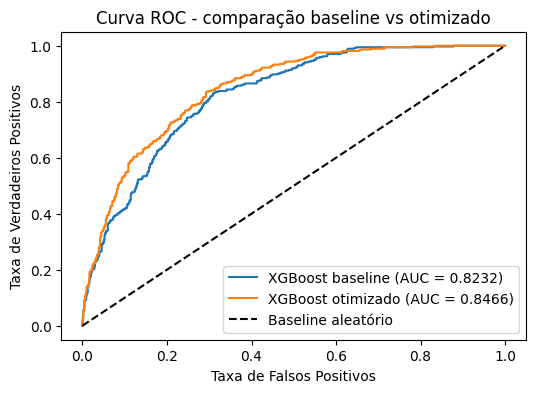

In [10]:
# vamo plotar as curvas ROC do modelo inicial e do otimizado pra gente comparar as performances

fpr_final, tpr_final, _ = roc_curve(y_teste, probabilidades_final)

plt.figure(figsize=(6, 4))
plt.plot(fpr_pipeline_xgb, tpr_pipeline_xgb, label=f'XGBoost baseline (AUC = {auc_pipeline_xgb:.4f})')
plt.plot(fpr_final, tpr_final, label=f'XGBoost otimizado (AUC = {auc_final:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Baseline aleatório')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - comparação baseline vs otimizado')
plt.legend()
plt.show()

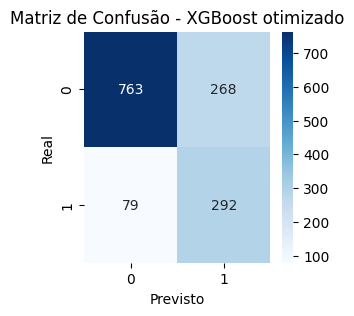

In [11]:
# e tbm a matriz de confusão pra avaliar se houve alguma diferença real pro modelo base

matriz_final = confusion_matrix(y_teste, y_pred_final)
plt.figure(figsize=(3, 3))
sns.heatmap(matriz_final, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - XGBoost otimizado')
plt.show()

o modelo otimizado manteve um recall de 0.79 para "cancelou", capturando 292 dos 371 churns reais e deixando escapar apenas 79. em relação ao baseline, o recall da classe minoritária subiu de 0.68 para 0.79, e o recall de "ficou" caiu de 0.79 para 0.74. essa é uma queda controlada, que mostra que o modelo ficou mais sensível ao churn sem se tornar agressivo demais na outra classe.

o custo ficou na precision de "cancelou", que, inclusive, mudou muito pouco (de 0.54 pra 0.52) resultando em 272 clientes que ficariam sendo sinalizados como churn. essa queda é consequência direta da escolha do scale_pos_weight, já que ao forçar o modelo a capturar mais churns reais, ele inevitavelmente passa a sinalizar alguns clientes que ficariam.

o AUC-ROC de 0.8466 no teste, próximo ao 0.8497 do CV, confirma que o modelo generaliza bem sem overfitting. a pequena diferença entre os dois já era esperada, já que o CV guiou a escolha dos hiperparâmetros, e o teste dá a estimativa honesta da performance real.

com um modelo que tem boa capacidade discriminativa e distribuição de probabilidades mais rica, a análise de limiar vai permitir identificar o ponto de operação ideal — onde o recall de "cancelou" se mantém em nível aceitável para o negócio e os falsos positivos ficam em um volume operacionalmente viável.

o threshold padrão de 0.5 é uma convenção, não uma decisão de negócio. vale inserir aqui uma análise de sensibilidade ao limiar pra entender, exatamente, como precisão, recall e F1 se comportam ao longo do espectro conforme a gente ajusta esse threshold, permitindo escolher o ponto de operação mais adequado à capacidade e à estratégia do time de retenção.

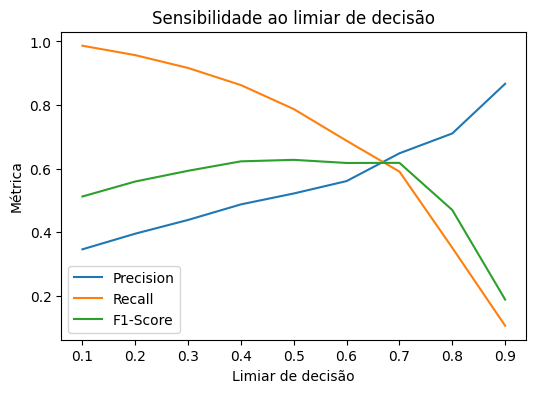

In [12]:
# vamo fazer a análise de sensibilidade ao limiar de decisão

from sklearn.metrics import precision_recall_fscore_support

limiares = np.arange(0.1, 1, 0.1)
precisions = []
recalls = []
f1_scores = []

for limiar in limiares:
    y_pred_lim = (probabilidades_final >= limiar).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_teste, y_pred_lim, average='binary', zero_division=0)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

plt.figure(figsize=(6, 4))
plt.plot(limiares, precisions, label='Precision')
plt.plot(limiares, recalls, label='Recall')
plt.plot(limiares, f1_scores, label='F1-Score')
plt.xlabel('Limiar de decisão')
plt.ylabel('Métrica')
plt.title('Sensibilidade ao limiar de decisão')
plt.legend()
plt.show()

In [13]:
# vamo identificar o limiar exato do pico de F1
# pra isso, vamo varrer de 0.5 a 0.8 com precisão de 0.01

from sklearn.metrics import f1_score

limiares_finos = np.arange(0.5, 0.8, 0.01)
f1_scores_finos = []

for limiar in limiares_finos:
    y_pred_lim = (probabilidades_final >= limiar).astype(int)
    f1 = f1_score(y_teste, y_pred_lim, zero_division=0)
    f1_scores_finos.append(f1)

limiar_otimo = limiares_finos[np.argmax(f1_scores_finos)]
y_pred_limiar_otimo = (probabilidades_final >= limiar_otimo).astype(int)

print(f"Limiar ótimo: {limiar_otimo:.2f}")
print(f"F1 máximo: {max(f1_scores_finos):.4f}")

Limiar ótimo: 0.58
F1 máximo: 0.6276


In [14]:
# vamo incluir tbm uma tabela de limiares pra gente ver como as métricas se comportam

df_limiares = pd.DataFrame({
    'limiar':    np.round(limiares, 1),
    'precision': np.round(precisions, 3),
    'recall':    np.round(recalls, 3),
    'f1':        np.round(f1_scores, 3)
})
print(df_limiares.to_string(index=False))

 limiar  precision  recall    f1
    0.1      0.346   0.987 0.512
    0.2      0.395   0.957 0.559
    0.3      0.438   0.916 0.593
    0.4      0.487   0.863 0.623
    0.5      0.521   0.787 0.627
    0.6      0.560   0.687 0.617
    0.7      0.648   0.590 0.618
    0.8      0.710   0.350 0.469
    0.9      0.867   0.105 0.188


In [15]:
# vamo incluir tbm uma tabela com uma análise de resultados em alguns thresholds

for t in [0.40, 0.5, 0.58, 0.70]:
    y_pred_t = (probabilidades_final >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_teste, y_pred_t).ravel()
    print(f'threshold {t}: VP={tp}, FP={fp}, FN={fn}')

threshold 0.4: VP=320, FP=337, FN=51
threshold 0.5: VP=292, FP=268, FN=79
threshold 0.58: VP=268, FP=215, FN=103
threshold 0.7: VP=219, FP=119, FN=152


o gráfico e a tabela mostram 3 possíveis zonas de operação:
- a primeira é entre 0.1 e 0.3, onde recall está acima de 0.92, mas precision está abaixo de 0.44. nessa zona, o modelo captura quase todos os churns reais, mas mais da metade dos acionamentos são desnecessários. Faz sentido se o custo de perder um cliente for muito alto e a ação de retenção for barata (um email automatizado, por exemplo);
- a segunda (e mais equilibrada) é entre 0.4 e 0.6. em 0.58 o f1 é máximo em 0.6276. em 0.4, o recall ainda está em 0.863 com precision de 0.487, capturando mais churns com custo moderado de falsos positivos. essa faixa é onde a maioria dos times de retenção vai querer operar;
- já na terceira, entre 0.7 e 0.9, precision sobe pra uma faixa que varia de 0.65 a 0.86, mas o recall cai drasticamente. em 0.9, o modelo captura apenas 10% dos churns reais. essa zona só faz sentido se a ação de retenção for muito cara e o time precisar de uma lista extremamente enxuta e confiável.

como no contexto de telecom em geral, as ações de retenção tem custo moderado, o threshold ideal está na zona mais equilibrada, entre 0.4 e 0.6. operar em 0.57 (que é o limiar ótimo) maximiza o f1 com menos falsos positivos, mas manter o threshold padrão de 0.5 reduz os churns sem ação de 103 pra 79, ao custo de 53 acionamentos desnecessários a mais (que faz sentido quando perder um cliente é mais caro do que uma ação de retenção).

então, dá pra considerar que seguir a convenção do threshold de 0.5, nesse contexto, é o mais adequado, mas tudo vai depender da estratégia e da capacidade operacional do time de retenção.

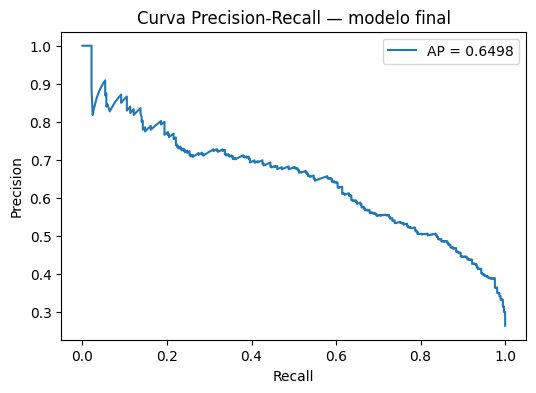

In [16]:
# vamo plotar a curva Precision-Recall pra seguir com a avaliação

from sklearn.metrics import precision_recall_curve, average_precision_score

precision_curve, recall_curve, _ = precision_recall_curve(y_teste, probabilidades_final)
ap = average_precision_score(y_teste, probabilidades_final)

plt.figure(figsize=(6, 4))
plt.plot(recall_curve, precision_curve, label=f'AP = {ap:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall — modelo final')
plt.legend()
plt.show()

a curva precision-recall sintetiza o trade-off do modelo ao longo de todos os thresholds possíveis. o AP (average precision) representa a área sob essa curva. em uma distribuição balanceada (50/50), um classificador aleatório teria AP de 0.5. no caso da distribuição do nosso dataset, a nossa baseline gira em torno de 0.27. sendo assim, um AP de 0.6498 confirma que o modelo tem poder discriminativo real sobre a classe minoritária.


a curva mostra que até um recall de aproximadamente 0.6, o modelo consegue manter precision em algo próximo a 0.65, ou seja, é possível capturar bem os churns reais com uma boa precisão nos acionamentos. a partir daí, capturar churns adicionais exige aceitar uma precision progressivamente menor, refletindo os casos mais ambíguos que o modelo só consegue capturar baixando o threshold.

o comportamento oscilante no início da curva, próximo ao recall zero, é apenas um artefato de interpolação do sklearn e não um comportamento real do modelo.

até aqui, o modelo sabe que um cliente vai cancelar. o que ele ainda não responde é o porquê, e sem isso, o time de retenção não tem base para agir de forma direcionada.

de maneira mais simples, a gente poderia usar o feature_importances nativo do XGBoost, que mede quantas vezes cada feature foi usada para splits nas árvores. mas essa é uma proxy de importância e não de impacto no resultado. então, pro nosso caso, o SHAP é mais adequado já que ele calcula a contribuição marginal real de cada feature para cada predição individual, baseado na teoria dos jogos (valores de Shapley).

isso permite dois níveis de análise:
- global, mostrando quais features mais impactam o churn em geral;
- e individual, explicando por que esse cliente específico tem X% de probabilidade de cancelar.

vamo usar o TreeExplainer, que é o método nativo do SHAP para modelos baseados em árvore, já que ele é computacionalmente eficiente e exato, sem aproximações. os valores SHAP gerados aqui também vão alimentar o RAG na fase 3, onde os motivos de churn identificados vão ser contextualizados com reclamações reais de clientes insatisfeitos.

In [17]:
# vamo extrair classificador XGBoost puro do modelo_final
# pq o TreeExplainer não precisa receber o pipeline inteiro

modelo_xgb = modelo_final.named_steps['classifier']
# como tiramos o pipeline inteiro, vamo ter que transformar o X_teste manualmente
X_teste_proc = modelo_final.named_steps['preprocessor'].transform(X_teste)

explainer = shap.TreeExplainer(modelo_xgb)
shap_values = explainer.shap_values(X_teste_proc)

# recuperar nomes das features após o preprocessor
feature_names = (
    preprocessor.named_transformers_['num'].feature_names_in_.tolist() +
    preprocessor.named_transformers_['bin'].feature_names_in_.tolist() +
    preprocessor.named_transformers_['nom'].get_feature_names_out().tolist()
)

print(f'shap_values shape: {shap_values.shape}')
print(f'features: {len(feature_names)}')

shap_values shape: (1402, 30)
features: 30


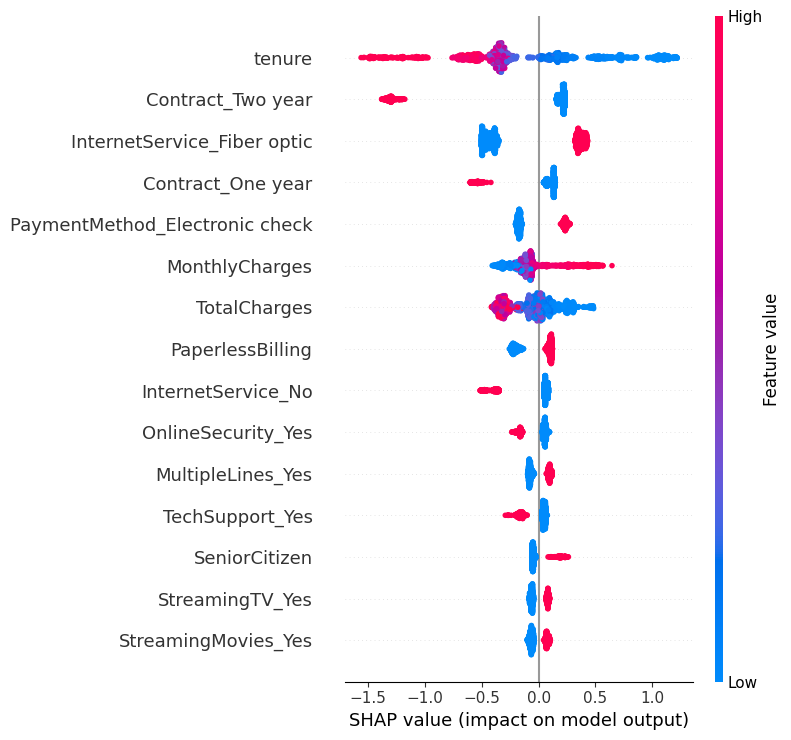

In [18]:
# vamo fazer o summary plot global

shap.summary_plot(
    shap_values,
    X_teste_proc,
    feature_names=feature_names,
    max_display=15,
    show=True
)

o summary plot mostra o impacto de cada feature na predição de churn para todos os clientes do conjunto de teste. cada ponto na linha horizontal representa um cliente. a posição do ponto diz quanto aquela feature empurrou a predição desse cliente para churn (direita, positivo) ou para não-churn (esquerda, negativo). caso os pontos estejam concentrados próximos do zero, significa que essa feature tem pouco impacto na maioria dos clientes, importando pouco para a decisão do modelo. já a cor indica o valor real da feature: vermelho significa que aquele cliente tem um valor alto para essa feature, enquanto azul significa valor baixo.

sabendo disso, dá pra gente perceber do resultado obtido:
- tenure é a feature com maior impacto individual no modelo (dá pra confirmar isso graças à distribuição dos pontos ao longo de toda a linha horizontal). clientes novos/com tenure baixo (pontos azuis) têm SHAP values predominantemente positivos, ou seja: aumentam a probabilidade de churn. enquanto que os clientes antigos/com tenure alto (pontos vermelhos), têm SHAP values negativos, ou seja: reduzem a probabilidade de churn;
- tipo de contrato aparece logo em seguida, dividido em duas features pelo OneHotEncoder: Contract_Two year e Contract_One year. pro caso desse tipo de variável, vermelho é um cliente que tem esse contrato, azul é um cliente que não tem. o Contract_Two year com pontos vermelhos puxa fortemente para a esquerda, mostrando que contratos de dois anos reduzem muito a probabilidade de churn. Contract_One year tem efeito similar, mas menor. já os clientes que não têm esses tipos de contrato (pontos azuis) são os clientes com contrato mês-a-mês, e essa categoria empurra bastante pra churn;
- InternetService_Fiber optic com valor alto (vermelho) puxa para churn, ou seja: clientes com fibra ótica têm maior probabilidade de cancelar;
- PaymentMethod_Electronic check e PaperlessBilling se comportam de forma semelhante, com valores altos empurrando pra churn;
- features como OnlineSecurity_Yes e TechSupport_Yes com valor alto puxam para a esquerda, ou seja, reduzem a probabilidade de churn.

essas features dominantes vão guiar diretamente a construção da tabela de evitabilidade na próxima etapa, mapeando cada motivo principal de churn em uma categoria acionável ou não pelo time de retenção.

de forma geral, todas as avaliações aqui estão completamente alinhadas com o que já foi discutido na EDA, quando percebemos e entendemos os motivos que estão relacionados ao churn ou não, o que nos confirma que o modelo tá realmente se comportando como era esperado.

algumas features apresentam uma divisão bem clara sobre a forma que aumentam ou reduzem a probabilidade de churn, mas nem sempre isso acontece. o ponto é que nenhuma feature sozinha determina o churn, já que o modelo toma decisões capturando interações entre elas. o SHAP value de uma feature para um cliente específico já tá considerando o contexto completo daquele cliente.

sendo assim, vamo incluir um waterfall plot individual aqui, já que ele vai ser mais informativo do que o summary plot pra casos específicos, mostrando quais features, naquele cliente, se combinaram para chegar naquela predição. mas, antes de plotar, vamo identificar os 3 perfis ilustrativos, analisando cada candidato e garantindo que cada waterfall conte uma história distinta.

In [19]:
# vamo montar um dataframe de apoio pra selecionar dos perfis
y_prob = probabilidades_final  #-> vai ter a probabilidade de churn de cada cliente

df_selecao = pd.DataFrame({
    'idx':           np.arange(len(y_prob)),
    'prob_churn':    y_prob,
    'tenure':        X_teste['tenure'].values,
    'contract':      X_teste['Contract'].values,
    'monthly_charges': X_teste['MonthlyCharges'].values,
})

# ------------------------------------------------------------------
# perfil 1 —> alto risco + motivo acionável
# prob alta + contrato mensal (que é o principal driver acionável segundo o summary
# plot) + charges altos (pra garantir que vamo ter uma história completa pra contar)

mask_p1 = ( #-> pra filtrar o df_selecao com esses critérios
    (df_selecao['prob_churn'] >= 0.75) &
    (df_selecao['contract'] == 'Month-to-month') &
    (df_selecao['monthly_charges'] >= 70) &
    # vamo incluir uma condição de tenure pro modelo não escolher um cliente cujo risco venha principalmente do tenure baixo
    (df_selecao['tenure'] >= 24)
)
candidatos_p1 = df_selecao[mask_p1].sort_values('prob_churn', ascending=False) #-> pra ordenar os candidatos
idx_alto_evitavel = candidatos_p1.iloc[0]['idx'] if len(candidatos_p1) else None #-> pra pegar o de maior risco

# ------------------------------------------------------------------
# perfil 2 —> alto risco + motivo não-acionável
# prob alta + tenure muito baixo (que é o principal driver estrutural)

mask_p2 = (
    (df_selecao['prob_churn'] >= 0.75) &
    (df_selecao['tenure'] <= 6) #-> pra confirmar que é um cliente novo
)
candidatos_p2 = df_selecao[mask_p2].sort_values('prob_churn', ascending=False)
idx_alto_nao_evit = candidatos_p2.iloc[0]['idx'] if len(candidatos_p2) else None

# ------------------------------------------------------------------
# perfil 3 — baixo risco
# prob baixa + tenure alto + contrato longo

mask_p3 = (
    (df_selecao['prob_churn'] <= 0.10) &
    (df_selecao['tenure'] >= 48) &
    (df_selecao['contract'].isin(['One year', 'Two year']))
)
candidatos_p3 = df_selecao[mask_p3].sort_values('prob_churn')
idx_baixo_risco = candidatos_p3.iloc[0]['idx'] if len(candidatos_p3) else None

# confirmar os escolhidos antes de plotar
for label, idx in [('alto evitável', idx_alto_evitavel),
                   ('alto não-evitável', idx_alto_nao_evit),
                   ('baixo risco', idx_baixo_risco)]:
    if idx is not None:
        row = df_selecao[df_selecao['idx'] == idx].iloc[0]
        print(f"{label}: idx={int(idx)} | prob={row['prob_churn']:.3f} | "
              f"tenure={int(row['tenure'])} | contrato={row['contract']} | "
              f"charges={row['monthly_charges']:.1f}")

alto evitável: idx=1105 | prob=0.834 | tenure=29 | contrato=Month-to-month | charges=98.5
alto não-evitável: idx=1004 | prob=0.967 | tenure=1 | contrato=Month-to-month | charges=100.8
baixo risco: idx=591 | prob=0.011 | tenure=72 | contrato=Two year | charges=20.3


In [20]:
# checar os top drivers de cada candidato antes de plotar
def top_drivers(idx, shap_values, feature_names, n=5):
    sv = shap_values[int(idx)]
    ordem = np.argsort(np.abs(sv))[::-1][:n]
    for i in ordem:
        print(f"  {feature_names[i]:<35} SHAP={sv[i]:+.4f}")

print("=== alto evitável ===")
top_drivers(idx_alto_evitavel, shap_values, feature_names)

print("\n=== alto não-evitável ===")
top_drivers(idx_alto_nao_evit, shap_values, feature_names)

print("\n=== baixo risco ===")
top_drivers(idx_baixo_risco, shap_values, feature_names)

=== alto evitável ===
  InternetService_Fiber optic         SHAP=+0.3856
  tenure                              SHAP=-0.3431
  PaymentMethod_Electronic check      SHAP=+0.2329
  Contract_Two year                   SHAP=+0.2142
  MonthlyCharges                      SHAP=+0.1939

=== alto não-evitável ===
  tenure                              SHAP=+1.0151
  TotalCharges                        SHAP=+0.3488
  InternetService_Fiber optic         SHAP=+0.3333
  MonthlyCharges                      SHAP=+0.3086
  Contract_Two year                   SHAP=+0.2197

=== baixo risco ===
  Contract_Two year                   SHAP=-1.3077
  tenure                              SHAP=-1.1901
  InternetService_Fiber optic         SHAP=-0.4175
  MonthlyCharges                      SHAP=-0.3603
  InternetService_No                  SHAP=-0.3515


o perfil 2 tá alinhado com o que precisamos. o tenure tá dominando com folga (SHAP=+1.0151) e puxando pro churn, e os drivers secundários tbm tão coerentes;

o perfil 3 tbm tá perfeito pro que a gente precisa, com tudo negativo e apontando pra estabilidade;

o problema aqui tá no perfil 1 que não tá mostrando exatamente o que era esperado pra ilustrar um waterfall. o valor de tenure serviu pro que se propôs (não deixar o modelo escolher um cliente cujo risco viesse principalmente do tenure baixo), mas o que ocupou essa posição de driver principal foi o InternetService_Fiber optic, que não é acionável.

então, vamo incluir uma iteração na lista dos candidatos já filtrados e ordenados por prob_churn, e escolher o primeiro que tenha um top driver acionável.

In [21]:
# vamo começar fazendo uma lista dos drivers acionáveis
drivers_acionaveis = {'Contract_Two year', 'MonthlyCharges',
                      'PaymentMethod_Electronic check', 'PaperlessBilling'}

idx_alto_evitavel = None #-> pra iterar entre os candidatos até achar o driver acionável
for _, row in candidatos_p1.iterrows():
    idx = int(row['idx'])
    sv = shap_values[idx]
    top_driver = feature_names[np.argmax(np.abs(sv))]
    if top_driver in drivers_acionaveis:
        idx_alto_evitavel = idx
        break

print(f"idx escolhido: {idx_alto_evitavel}")
top_drivers(idx_alto_evitavel, shap_values, feature_names)

row = df_selecao[df_selecao['idx'] == idx_alto_evitavel].iloc[0]
print()
print(f"alto evitável: idx={int(row['idx'])} | prob={row['prob_churn']:.3f} | "
      f"tenure={int(row['tenure'])} | contrato={row['contract']} | "
      f"charges={row['monthly_charges']:.1f}")

idx escolhido: 583
  MonthlyCharges                      SHAP=+0.4597
  InternetService_Fiber optic         SHAP=+0.3758
  tenure                              SHAP=-0.3384
  TotalCharges                        SHAP=-0.3184
  PaymentMethod_Electronic check      SHAP=+0.2348

alto evitável: idx=583 | prob=0.779 | tenure=34 | contrato=Month-to-month | charges=106.3


pronto! agora o MonthlyCharges tá no topo como driver acionável. fibra ótica ainda aparece em segundo, mas como divide espaço, tá ok. a história desse caso gira em torno de: cliente que paga caro, mês a mês, com fibra ótica", e isso serve bem pra ilustrar o waterfall. vamo seguir pra essa etapa.

In [22]:
# vamo inverter a normalização das colunas numéricas
# pra exibir os valores originais no waterfall

#pra saber quantas colunas inverter
num_features = preprocessor.named_transformers_['num'].feature_names_in_.tolist()
scaler = preprocessor.named_transformers_['num'] #-> pra fzr a inversão
X_teste_num_original = scaler.inverse_transform(
    X_teste_proc[:, :len(num_features)]
)
X_teste_display = np.hstack([ #-> pra montar o array final
    X_teste_num_original,
    X_teste_proc[:, len(num_features):]
])

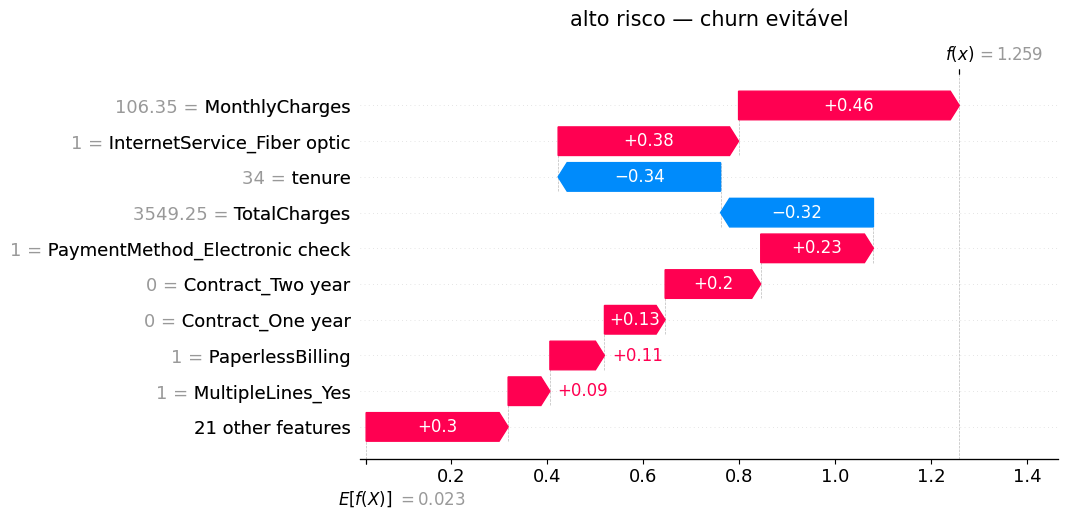

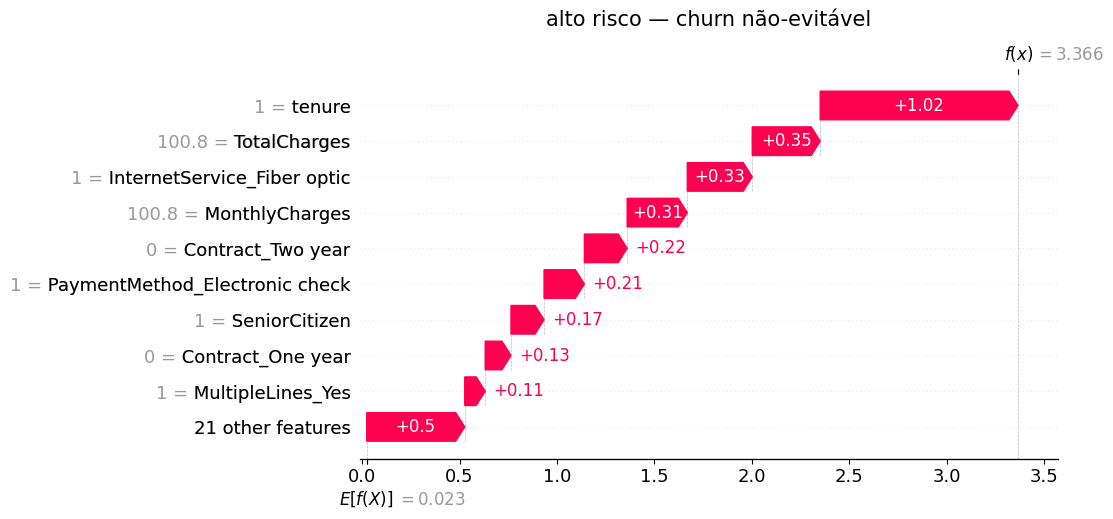

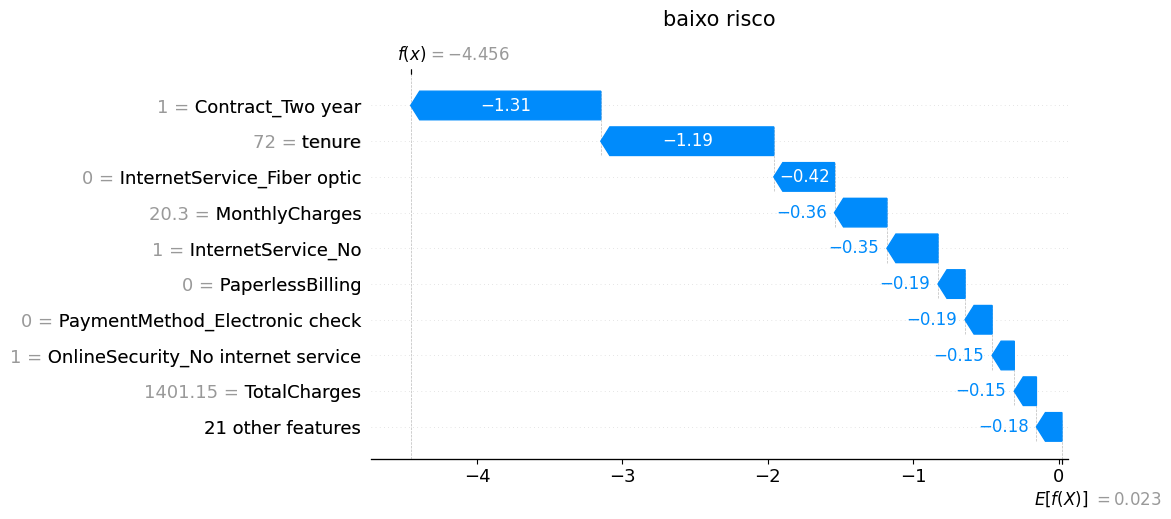

In [23]:
# vamo preencher os idx que a gente já encontrou nos seus devidos lugares

idx_alto_evitavel    = 583
idx_alto_nao_evit    = 1004
idx_baixo_risco      = 591

for idx, titulo in [
    (idx_alto_evitavel, 'alto risco — churn evitável'),
    (idx_alto_nao_evit, 'alto risco — churn não-evitável'),
    (idx_baixo_risco,   'baixo risco')
]:
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_teste_display[idx], #-> vamo usar os valores originais, sem normalizar
            feature_names=feature_names
        ),
        show=False
    )

    plt.gcf().set_size_inches(9, 5)
    plt.title(titulo, fontsize=15, pad=13)
    plt.show()

os plots mostram exatamente o que se esperava:
- no perfil 1 o modelo parte da probabilidade média do dataset (E[f(X)] = 0.023) e vai acumulando contribuições até chegar em f(x) = 1.259. tudo continua alinhado com o que viemos analisando desde o começo do projeto: uma conta alta é o que mais empurra pro churn, da mesma forma que a fibra ótica tbm é um grande fator de risco. seguindo a mesma linha, o método de pagamento ser Electronic check e a ausência de um contrato longo tbm contribuem pro risco. por outro lado, 34 meses de relacionamento seguram um pouco o cliente;
- no perfil 2, o modelo parte do E[f(X)] = 0.023 e chega a um valor de f(x) bem mais alto (3.366). não há nenhum fator de proteção nesse cliente. ele é um cliente com 1 mês de casa e já paga caro (e ainda tem fibra ótica), então o modelo reconhece esse perfil como quase certo de cancelar;
- já no caso do perfil  3, o modelo sai do E[f(X)] = 0.023 e cada feature vai reduzindo a probabilidade de churn até chegar em f(x) = -4.456. a história aqui é bem clara: é um cliente antigo, com contrato longo, conta barata, sem os serviços que o modelo aprendeu a associar com churn. de forma geral, o modelo tá bem confiante pq não tem nenhum sinal de alerta ligado nesse caso.

o waterfall mostra exatamente onde dá pra agir:
- no perfil 1, o contrato mensal e o charges alto são os dois drivers acionáveis com mais peso. nesse caso, uma oferta de upgrade de contrato com desconto na mensalidade atacaria os dois principais motivos;
- o perfil 2 não mostra uma alavanca de retenção clara. o driver dominante aqui é o tenure=1, mostrando que o cliente acabou de chegar na casa, então ele não tem histórico de engajamento. diferente do perfil 1, aqui charges altos, o tipo de contrato e até a fibra ótica, são apenas drivers secundários. o verdadeiro vilão é realmente o tenure, o que reforça que o problema é estrutural e sem uma alavanca direta pra agir.

primeiro o summary plot mostrou o comportamento global do modelo, dizendo quais features importam para o conjunto todo. os waterfall plots desceram para o nível individual, mostrando como essas features se combinaram em casos específicos.

o próximo passo é generalizar: em vez de olhar 3 casos ilustrativos, vamo fazer o mesmo raciocínio pra todos os clientes do conjunto de teste de forma sistemática, identificando quais são os motivos dominantes de churn de cada um. essa exportação também vai ser a ponte entre o modelo e a fase 3 do projeto, onde esses motivos vão contextualizar as predições com informações externas.

In [24]:
# vamo pegar as 3 features com maior valor de SHAP pra cada cliente no teste
shap_abs = np.abs(shap_values)

top3_features = []
top3_valores  = []

for i in range(len(shap_values)):
    idx_sorted = np.argsort(shap_abs[i])[::-1][:3]
    top3_features.append([feature_names[j] for j in idx_sorted])
    top3_valores.append([float(shap_values[i][j]) for j in idx_sorted])

df_shap = pd.DataFrame({
    'churn_prob':   y_prob,
    'predicao':     y_pred_final,
    'feature_1':    [f[0] for f in top3_features],
    'feature_2':    [f[1] for f in top3_features],
    'feature_3':    [f[2] for f in top3_features],
    'shap_1':       [v[0] for v in top3_valores],
    'shap_2':       [v[1] for v in top3_valores],
    'shap_3':       [v[2] for v in top3_valores],
}, index=X_teste.index)

print(df_shap.head())

      churn_prob  predicao                    feature_1  \
743     0.618509         1                       tenure   
668     0.055756         0            Contract_Two year   
5741    0.184076         0            Contract_Two year   
5449    0.564532         1  InternetService_Fiber optic   
2020    0.588473         1                       tenure   

                        feature_2                    feature_3    shap_1  \
743   InternetService_Fiber optic            Contract_Two year  0.559060   
668                        tenure  InternetService_Fiber optic -1.345854   
5741                       tenure  InternetService_Fiber optic -1.270810   
5449                       tenure            Contract_Two year  0.395350   
2020  InternetService_Fiber optic                 TotalCharges  0.841367   

        shap_2    shap_3  
743  -0.433777  0.226106  
668  -0.574071 -0.366996  
5741 -0.404619  0.340169  
5449 -0.337855  0.226922  
2020 -0.388089  0.242834  


com o top-3 exportado, o próximo passo que a gente precisa dar é classificar cada predição de churn por evitabilidade, mapeando se o motivo dominante identificado pelo SHAP é algo que o time de retenção pode endereçar ou não, e qual seria a ação recomendada para cada caso.

a gente já viu a lista que o summary plot retornou como as mais impactantes na predição do churn, mas pra estabelecer as regras de evitabilidade, nem todas precisam ser listadas, já que apenas as que aparecem como feature_1 no df_shap vão acionar a regra.

então, antes de fechar as regras de evitabilidade em si, vamo saber quais exatamente precisam estar nessa lista

In [25]:
# vamo ver quais features (e a frequência) dominam as predições de churn

print(df_shap[df_shap['predicao'] == 1]['feature_1'].value_counts())

feature_1
tenure                         277
InternetService_Fiber optic    253
Contract_One year               15
MonthlyCharges                  15
Name: count, dtype: int64


a lógica da evitabilidade é, realmente, classificar o cliente pelo motivo dominante, ou seja, aquele que mais pesou na predição. a gente tem tenure com 277 casos, InternetService_Fiber optic com 253 (eles juntos já cobrem a esmagadora maioria das predições de churn), Contract_One year e MonthlyCharges com 15 cada. então, vamo focar os esforços em mapear essas 4 regras.

In [26]:
# vamo fazer as regras de evitabilidade

REGRAS_EVITABILIDADE = [
    ('tenure',                          False, 'cliente novo — priorizar onboarding ativo e acompanhamento nos primeiros 3 meses'),
    ('InternetService_Fiber optic',     True,  'acionar pesquisa de satisfação com o serviço de fibra e oferecer crédito em caso de instabilidade reportada'),
    ('Contract_One year',               False, 'cliente com contrato anual — verificar proximidade do vencimento e antecipar oferta de renovação com benefício'),
    ('MonthlyCharges',                  True,  'oferecer downgrade de plano ou desconto por fidelidade de 12 meses')
]

def classificar_evitabilidade(feature_1):
    for padrao, evitavel, acao in REGRAS_EVITABILIDADE:
        if padrao in str(feature_1):
            return evitavel, acao
    return None, 'avaliar manualmente'

df_shap[['evitavel', 'acao_sugerida']] = df_shap['feature_1'].apply(
    lambda f: pd.Series(classificar_evitabilidade(f))
)

print(df_shap[df_shap['predicao'] == 1][['churn_prob', 'feature_1', 'evitavel', 'acao_sugerida']].head(10))

      churn_prob                    feature_1 evitavel  \
743     0.618509                       tenure    False   
5449    0.564532  InternetService_Fiber optic     True   
2020    0.588473                       tenure    False   
3067    0.642462                       tenure    False   
1168    0.746944                       tenure    False   
3171    0.839236                       tenure    False   
531     0.895292                       tenure    False   
6149    0.797867  InternetService_Fiber optic     True   
1038    0.705985  InternetService_Fiber optic     True   
3088    0.533423                       tenure    False   

                                          acao_sugerida  
743   cliente novo — priorizar onboarding ativo e ac...  
5449  acionar pesquisa de satisfação com o serviço d...  
2020  cliente novo — priorizar onboarding ativo e ac...  
3067  cliente novo — priorizar onboarding ativo e ac...  
1168  cliente novo — priorizar onboarding ativo e ac...  
3171  cliente

com a evitabilidade classificada e as ações sugeridas mapeadas, o modelo tá completo. o próximo passo é salvar os artefatos que vão alimentar as fases seguintes do projeto:

- xgboost_final.joblib — modelo para predições em tempo real no Streamlit;
- churn_predictions.csv — tabela completa por cliente com probabilidade, predição, top-3 features, evitabilidade e ação sugerida;
- evitabilidade_rules.json — regras de classificação aplicadas pelo Streamlit.

esses três arquivos são o contrato entre a fase 2 e as fases 3 e 4 do projeto.

In [27]:
# vamo começar montando o churn_predictions.csv
df_predicoes = X_teste.copy()
df_predicoes['churn_prob']    = y_prob
df_predicoes['predicao']      = y_pred_final
df_predicoes['real']          = y_teste.values
df_predicoes['feature_1']     = df_shap['feature_1'].values
df_predicoes['feature_2']     = df_shap['feature_2'].values
df_predicoes['feature_3']     = df_shap['feature_3'].values
df_predicoes['evitavel']      = df_shap['evitavel'].values
df_predicoes['acao_sugerida'] = df_shap['acao_sugerida'].values

# vamo salvar localmente
joblib.dump(modelo_final, 'xgboost_final.joblib')
df_predicoes.to_csv('churn_predictions.csv', index=True)

# vamo serializar regras de evitabilidade
regras_json = [
    {'padrao': p, 'evitavel': e, 'acao': a}
    for p, e, a in REGRAS_EVITABILIDADE
]
with open('evitabilidade_rules.json', 'w', encoding='utf-8') as f:
    json.dump(regras_json, f, ensure_ascii=False, indent=2)

# vamo confirmar que os artefatos foram criados como esperado
print('artefatos salvos:')
print(f'  modelo:     xgboost_final.joblib')
print(f'  predicoes:  churn_predictions.csv      ({len(df_predicoes)} linhas)')
print(f'  regras:     evitabilidade_rules.json   ({len(regras_json)} regras)')

artefatos salvos:
  modelo:     xgboost_final.joblib
  predicoes:  churn_predictions.csv      (1402 linhas)
  regras:     evitabilidade_rules.json   (4 regras)


In [28]:
# e, por último, vamo salvar os arquivos resultantes dessa fase 2 no drive

import os
from google.colab import drive
drive.mount('/content/drive') #-> pra montar o drive

os.makedirs('/content/drive/MyDrive/churn-intelligence/models', exist_ok=True)
os.makedirs('/content/drive/MyDrive/churn-intelligence/data', exist_ok=True)

joblib.dump(modelo_final, '/content/drive/MyDrive/churn-intelligence/models/xgboost_final.joblib')
df_predicoes.to_csv('/content/drive/MyDrive/churn-intelligence/data/churn_predictions.csv', index=True)

with open('/content/drive/MyDrive/churn-intelligence/data/evitabilidade_rules.json', 'w', encoding='utf-8') as f:
    json.dump(regras_json, f, ensure_ascii=False, indent=2)

print('artefatos salvos no Drive:')
print(f'  modelo:     models/xgboost_final.joblib')
print(f'  predicoes:  data/churn_predictions.csv      ({len(df_predicoes)} linhas)')
print(f'  regras:     data/evitabilidade_rules.json   ({len(regras_json)} regras)')

Mounted at /content/drive
artefatos salvos no Drive:
  modelo:     models/xgboost_final.joblib
  predicoes:  data/churn_predictions.csv      (1402 linhas)
  regras:     data/evitabilidade_rules.json   (4 regras)
